In [1]:
"""
Random Forest + XGBoost on original data, engineered, pca and smote
==========================
Notebook: 06_Advanced_Models_RF_XGB.ipynb
Date: [Dec 10 2025]

Goal: Train Random Forest + XGBoost on multiple feature sets, compare performance.
Input: X_train_final.csv, X_test_final.csv, y_train.csv, y_test.csv,
X_train_engineered.csv, X_test_engineered.csv, X_train_pca.csv, X_test_pca.csv
###Output: X_train_engineered.csv, X_test_engineered.csv
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.model_selection import cross_val_score, StratifiedKFold
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

# Load all datasets
X_train_orig = pd.read_csv('X_train_final_v2.csv')  # 102 original features
X_test_orig = pd.read_csv('X_test_final_v2.csv')

X_train_eng = pd.read_csv('X_train_engineered.csv')  # 130 engineered
X_test_eng = pd.read_csv('X_test_engineered.csv')

X_train_pca = pd.read_csv('X_train_pca.csv')  # 74 PCA components
X_test_pca = pd.read_csv('X_test_pca.csv')

X_train_smote = pd.read_csv('X_train_combined.csv')
y_train_smote = pd.read_csv('y_train_combined.csv').squeeze()

y_train = pd.read_csv('y_train.csv').squeeze()
y_test = pd.read_csv('y_test.csv').squeeze()

from sklearn.preprocessing import LabelEncoder

# Encode target labels for XGBoost (needs numeric)
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Save mapping for reference
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f"\nLabel mapping: {label_mapping}")

# Keep original for RF, use encoded for XGBoost
y_train_xgb = y_train_encoded
y_test_xgb = y_test_encoded

print("Loaded datasets:")
print(f"  Original: {X_train_orig.shape}")
print(f"  Engineered: {X_train_eng.shape}")
print(f"  PCA: {X_train_pca.shape}")
print(f"  Target: {y_train.shape}")
print(f"  X_train_smote: {X_train_smote.shape}")
print(f"  y_train_smote: {y_train_smote.shape}")
print(f"\nSMOTE class distribution:")
print(y_train_smote.value_counts())


Label mapping: {'F': 0, 'G': 1, 'P': 2}
Loaded datasets:
  Original: (1236125, 102)
  Engineered: (1236125, 130)
  PCA: (1236125, 74)
  Target: (1236125,)
  X_train_smote: (600000, 102)
  y_train_smote: (600000,)

SMOTE class distribution:
BRIDGE_CONDITION
F    200000
G    200000
P    200000
Name: count, dtype: int64


In [2]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name, dataset_name):
    """
    Train model, evaluate, return results dict
    """
    start_time = time.time()
    
    # Train
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Determine if using string or numeric labels
    is_string_labels = isinstance(y_test.iloc[0] if hasattr(y_test, 'iloc') else y_test[0], str)
    
    # Metrics (work with any label type)
    accuracy = accuracy_score(y_test, y_pred)
    precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    # Per-class metrics - get ALL classes, then index by actual values
    if is_string_labels:
        # String labels: G, F, P
        recall_per_class = recall_score(y_test, y_pred, average=None, zero_division=0, labels=['G', 'F', 'P'])
        precision_per_class = precision_score(y_test, y_pred, average=None, zero_division=0, labels=['G', 'F', 'P'])
        f1_per_class = f1_score(y_test, y_pred, average=None, zero_division=0, labels=['G', 'F', 'P'])
        
        # Order is [G, F, P]
        recall_G, recall_F, recall_P = recall_per_class[0], recall_per_class[1], recall_per_class[2]
        precision_G, precision_F, precision_P = precision_per_class[0], precision_per_class[1], precision_per_class[2]
        f1_G, f1_F, f1_P = f1_per_class[0], f1_per_class[1], f1_per_class[2]
    else:
        # Numeric labels: F=0, G=1, P=2
        recall_per_class = recall_score(y_test, y_pred, average=None, zero_division=0, labels=[0, 1, 2])
        precision_per_class = precision_score(y_test, y_pred, average=None, zero_division=0, labels=[0, 1, 2])
        f1_per_class = f1_score(y_test, y_pred, average=None, zero_division=0, labels=[0, 1, 2])
        
        # Order is [F=0, G=1, P=2]
        recall_F, recall_G, recall_P = recall_per_class[0], recall_per_class[1], recall_per_class[2]
        precision_F, precision_G, precision_P = precision_per_class[0], precision_per_class[1], precision_per_class[2]
        f1_F, f1_G, f1_P = f1_per_class[0], f1_per_class[1], f1_per_class[2]
    
    results = {
        'model': model_name,
        'dataset': dataset_name,
        'n_features': X_train.shape[1],
        'train_time': train_time,
        'accuracy': accuracy,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'recall_G': recall_G,
        'recall_F': recall_F,
        'recall_P': recall_P,
        'precision_P': precision_P,
        'f1_P': f1_P
    }
    
    print(f"\n{model_name} on {dataset_name}:")
    print(f"  Accuracy: {accuracy:.3f}")
    print(f"  F1 (macro): {f1_macro:.3f}")
    print(f"  Recall Poor: {recall_P:.3f} {'✓' if recall_P >= 0.95 else '✗ (target: 95%)'}")
    print(f"  Training time: {train_time:.1f}s")
    
    return results, model, y_pred

results_list = []

In [3]:
print("RANDOM FOREST: ORIGINAL FEATURES (102)")
print("="*60)

rf_orig = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=100,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

results, model, preds = evaluate_model(
    rf_orig, X_train_orig, y_train, X_test_orig, y_test,
    'Random Forest', 'Original (102 features)'
)
results_list.append(results)

# Save model
with open('rf_original.pkl', 'wb') as f:
    pickle.dump(model, f)

RANDOM FOREST: ORIGINAL FEATURES (102)

Random Forest on Original (102 features):
  Accuracy: 0.756
  F1 (macro): 0.721
  Recall Poor: 0.870 ✗ (target: 95%)
  Training time: 351.9s


In [4]:
print("RANDOM FOREST: ENGINEERED FEATURES (130)")
print("="*60)

rf_eng = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=100,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

results, model, preds = evaluate_model(
    rf_eng, X_train_eng, y_train, X_test_eng, y_test,
    'Random Forest', 'Engineered (130 features)'
)
results_list.append(results)

with open('rf_engineered.pkl', 'wb') as f:
    pickle.dump(model, f)

RANDOM FOREST: ENGINEERED FEATURES (130)

Random Forest on Engineered (130 features):
  Accuracy: 0.754
  F1 (macro): 0.720
  Recall Poor: 0.870 ✗ (target: 95%)
  Training time: 422.0s


In [5]:
print("RANDOM FOREST: PCA FEATURES (74)")
print("="*60)

rf_pca = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=100,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

results, model, preds = evaluate_model(
    rf_pca, X_train_pca, y_train, X_test_pca, y_test,
    'Random Forest', 'PCA (74 components)'
)
results_list.append(results)

with open('rf_pca.pkl', 'wb') as f:
    pickle.dump(model, f)

RANDOM FOREST: PCA FEATURES (74)

Random Forest on PCA (74 components):
  Accuracy: 0.736
  F1 (macro): 0.698
  Recall Poor: 0.806 ✗ (target: 95%)
  Training time: 1627.0s


In [6]:
print("RANDOM FOREST: SMOTE BALANCED DATA")
print("="*60)
    
rf_smote = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=100,
    min_samples_leaf=50,
    class_weight=None,  # No class weights needed with SMOTE
    random_state=42,
    n_jobs=-1
)
    
results, model, preds = evaluate_model(
    rf_smote, X_train_smote, y_train_smote, X_test_orig, y_test,
    'Random Forest', 'SMOTE Balanced'
)
results_list.append(results)
    
with open('rf_smote.pkl', 'wb') as f:
    pickle.dump(model, f)

RANDOM FOREST: SMOTE BALANCED DATA

Random Forest on SMOTE Balanced:
  Accuracy: 0.744
  F1 (macro): 0.708
  Recall Poor: 0.812 ✗ (target: 95%)
  Training time: 202.4s


In [7]:
print("XGBOOST: ORIGINAL FEATURES (102)")
print("="*60)

# Calculate scale_pos_weight
class_counts_encoded = pd.Series(y_train_xgb).value_counts()
scale_pos_weight = (class_counts_encoded.get(0, 0) + class_counts_encoded.get(1, 0)) / class_counts_encoded.get(2, 1)

xgb_orig = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

results, model, preds = evaluate_model(
    xgb_orig, X_train_orig, y_train_xgb, X_test_orig, y_test_xgb,
    'XGBoost', 'Original (102 features)'
)
results_list.append(results)

with open('xgb_original.pkl', 'wb') as f:
    pickle.dump(model, f)

XGBOOST: ORIGINAL FEATURES (102)

XGBoost on Original (102 features):
  Accuracy: 0.779
  F1 (macro): 0.744
  Recall Poor: 0.556 ✗ (target: 95%)
  Training time: 155.3s


In [8]:
print("XGBOOST: ENGINEERED FEATURES (130)")
print("="*60)

xgb_eng = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

results, model, preds = evaluate_model(
    xgb_eng, X_train_eng, y_train_xgb, X_test_eng, y_test_xgb,
    'XGBoost', 'Engineered (130 features)'
)
results_list.append(results)

with open('xgb_engineered.pkl', 'wb') as f:
    pickle.dump(model, f)

XGBOOST: ENGINEERED FEATURES (130)

XGBoost on Engineered (130 features):
  Accuracy: 0.779
  F1 (macro): 0.743
  Recall Poor: 0.555 ✗ (target: 95%)
  Training time: 193.2s


In [9]:
print("XGBOOST: PCA FEATURES (74)")
print("="*60)

xgb_pca = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

results, model, preds = evaluate_model(
    xgb_pca, X_train_pca, y_train_xgb, X_test_pca, y_test_xgb,
    'XGBoost', 'PCA (74 components)'
)
results_list.append(results)

with open('xgb_pca.pkl', 'wb') as f:
    pickle.dump(model, f)

XGBOOST: PCA FEATURES (74)

XGBoost on PCA (74 components):
  Accuracy: 0.735
  F1 (macro): 0.662
  Recall Poor: 0.363 ✗ (target: 95%)
  Training time: 192.9s


In [10]:
print("XGBOOST: SMOTE BALANCED DATA")
print("="*60)

y_train_smote_xgb = label_encoder.transform(y_train_smote)

xgb_smote = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,  # Balanced already
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)
    
results, model, preds = evaluate_model(
    xgb_smote, X_train_smote, y_train_smote_xgb, X_test_orig, y_test_xgb,
    'XGBoost', 'SMOTE Balanced'
)
results_list.append(results)
    
with open('xgb_smote.pkl', 'wb') as f:
    pickle.dump(model, f)

XGBOOST: SMOTE BALANCED DATA

XGBoost on SMOTE Balanced:
  Accuracy: 0.758
  F1 (macro): 0.727
  Recall Poor: 0.756 ✗ (target: 95%)
  Training time: 91.7s


In [11]:
print("MODEL COMPARISON")
print("="*60)

results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values('recall_P', ascending=False)

print("\nAll Models (sorted by Poor class recall):")
print(results_df[['model', 'dataset', 'n_features', 'accuracy', 'f1_macro', 'recall_P', 'train_time']].to_string(index=False))

results_df.to_csv('rf_xgb_results.csv', index=False)
print("\nSaved: rf_xgb_results.csv")

# Highlight best model for Poor recall
best_idx = results_df['recall_P'].idxmax()
best_model = results_df.loc[best_idx]

print(f"\nBEST MODEL FOR POOR CLASS RECALL:")
print(f"  {best_model['model']} on {best_model['dataset']}")
print(f"  Recall (Poor): {best_model['recall_P']:.3f}")
print(f"  F1 (Poor): {best_model['f1_P']:.3f}")
print(f"  Training time: {best_model['train_time']:.1f}s")

if best_model['recall_P'] >= 0.95:
    print("\n✓ MEETS 95% RECALL TARGET")
else:
    print(f"\n✗ Below 95% target (deficit: {0.95 - best_model['recall_P']:.3f})")

MODEL COMPARISON

All Models (sorted by Poor class recall):
        model                   dataset  n_features  accuracy  f1_macro  recall_P  train_time
Random Forest   Original (102 features)         102  0.756099  0.720605  0.869905  351.946702
Random Forest Engineered (130 features)         130  0.754034  0.719637  0.869569  421.966434
Random Forest            SMOTE Balanced         102  0.744366  0.708485  0.812451  202.439882
Random Forest       PCA (74 components)          74  0.736335  0.697595  0.806069 1627.017528
      XGBoost            SMOTE Balanced         102  0.757857  0.727266  0.756315   91.700190
      XGBoost   Original (102 features)         102  0.779270  0.743550  0.555931  155.330220
      XGBoost Engineered (130 features)         130  0.779198  0.743338  0.554852  193.167634
      XGBoost       PCA (74 components)          74  0.735143  0.661628  0.363128  192.900507

Saved: rf_xgb_results.csv

BEST MODEL FOR POOR CLASS RECALL:
  Random Forest on Original (102

In [12]:
print("MODEL COMPARISON")
print("="*60)

results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values('recall_P', ascending=False)

print("\nAll Models (sorted by Poor class recall):")
print(results_df[['model', 'dataset', 'n_features', 'accuracy', 'f1_macro', 'recall_P', 'train_time']].to_string(index=False))

results_df.to_csv('rf_xgb_results.csv', index=False)
print("\nSaved: rf_xgb_results.csv")

# Highlight best model for Poor recall
best_idx = results_df['recall_P'].idxmax()
best_model = results_df.loc[best_idx]

print(f"\nBEST MODEL FOR POOR CLASS RECALL:")
print(f"  {best_model['model']} on {best_model['dataset']}")
print(f"  Recall (Poor): {best_model['recall_P']:.3f}")
print(f"  F1 (Poor): {best_model['f1_P']:.3f}")
print(f"  Training time: {best_model['train_time']:.1f}s")

if best_model['recall_P'] >= 0.95:
    print("\n✓ MEETS 95% RECALL TARGET")
else:
    print(f"\n✗ Below 95% target (deficit: {0.95 - best_model['recall_P']:.3f})")

MODEL COMPARISON

All Models (sorted by Poor class recall):
        model                   dataset  n_features  accuracy  f1_macro  recall_P  train_time
Random Forest   Original (102 features)         102  0.756099  0.720605  0.869905  351.946702
Random Forest Engineered (130 features)         130  0.754034  0.719637  0.869569  421.966434
Random Forest            SMOTE Balanced         102  0.744366  0.708485  0.812451  202.439882
Random Forest       PCA (74 components)          74  0.736335  0.697595  0.806069 1627.017528
      XGBoost            SMOTE Balanced         102  0.757857  0.727266  0.756315   91.700190
      XGBoost   Original (102 features)         102  0.779270  0.743550  0.555931  155.330220
      XGBoost Engineered (130 features)         130  0.779198  0.743338  0.554852  193.167634
      XGBoost       PCA (74 components)          74  0.735143  0.661628  0.363128  192.900507

Saved: rf_xgb_results.csv

BEST MODEL FOR POOR CLASS RECALL:
  Random Forest on Original (102

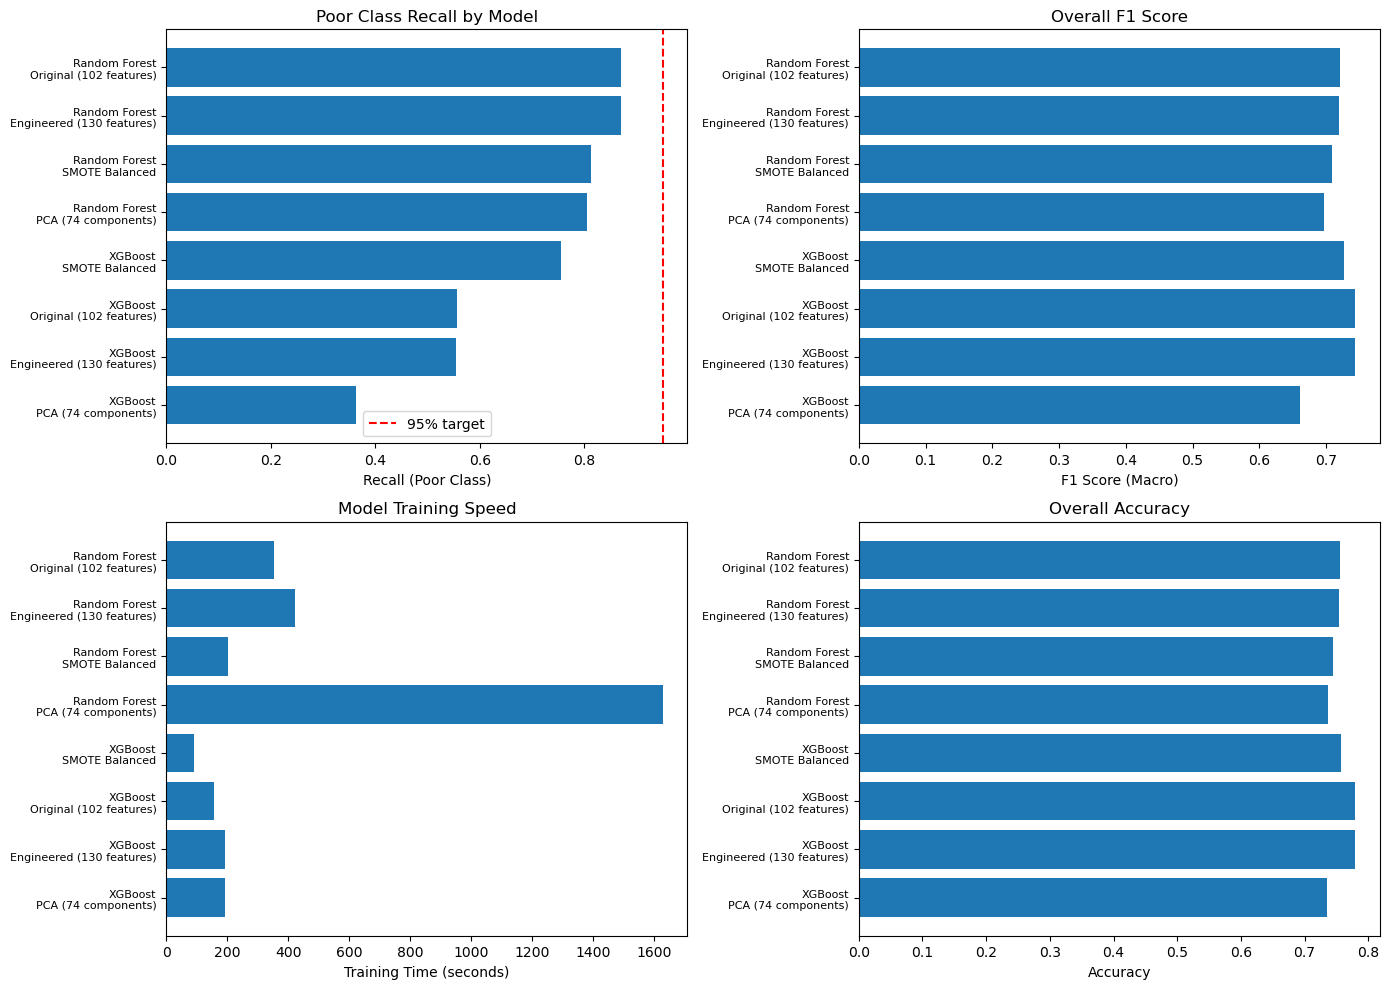

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Recall comparison
axes[0, 0].barh(range(len(results_df)), results_df['recall_P'])
axes[0, 0].set_yticks(range(len(results_df)))
axes[0, 0].set_yticklabels([f"{r['model']}\n{r['dataset']}" for _, r in results_df.iterrows()], fontsize=8)
axes[0, 0].set_xlabel('Recall (Poor Class)')
axes[0, 0].set_title('Poor Class Recall by Model')
axes[0, 0].axvline(0.95, color='red', linestyle='--', label='95% target')
axes[0, 0].legend()
axes[0, 0].invert_yaxis()

# Plot 2: F1 comparison
axes[0, 1].barh(range(len(results_df)), results_df['f1_macro'])
axes[0, 1].set_yticks(range(len(results_df)))
axes[0, 1].set_yticklabels([f"{r['model']}\n{r['dataset']}" for _, r in results_df.iterrows()], fontsize=8)
axes[0, 1].set_xlabel('F1 Score (Macro)')
axes[0, 1].set_title('Overall F1 Score')
axes[0, 1].invert_yaxis()

# Plot 3: Training time
axes[1, 0].barh(range(len(results_df)), results_df['train_time'])
axes[1, 0].set_yticks(range(len(results_df)))
axes[1, 0].set_yticklabels([f"{r['model']}\n{r['dataset']}" for _, r in results_df.iterrows()], fontsize=8)
axes[1, 0].set_xlabel('Training Time (seconds)')
axes[1, 0].set_title('Model Training Speed')
axes[1, 0].invert_yaxis()

# Plot 4: Accuracy
axes[1, 1].barh(range(len(results_df)), results_df['accuracy'])
axes[1, 1].set_yticks(range(len(results_df)))
axes[1, 1].set_yticklabels([f"{r['model']}\n{r['dataset']}" for _, r in results_df.iterrows()], fontsize=8)
axes[1, 1].set_xlabel('Accuracy')
axes[1, 1].set_title('Overall Accuracy')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig('rf_xgb_comparison.png', dpi=300, bbox_inches='tight')
plt.show()